<a href="https://colab.research.google.com/github/shreya-25/P4XI7ONWH3Z7Jls2/blob/main/Customer_Satisfaction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Predict Customer Satisfaction

In [1]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

# Replace with your actual uploaded filename
df = pd.read_csv("ACME-HappinessSurvey2020.csv")

df.head()

Saving ACME-HappinessSurvey2020.csv to ACME-HappinessSurvey2020 (1).csv


,Y,X1,X2,X3,X4,X5,X6
0,0,3,3,3,4,2,4
1,0,3,2,3,5,4,3
2,1,5,3,3,3,3,5
3,0,5,4,3,3,3,5
4,0,5,4,3,3,3,5


In [5]:
df.shape

(126, 7)

In [6]:
def check_unique_values(df):
    for column in df.columns:
        print(f"\nColumn: {column}")
        print(f"Number of unique values: {df[column].nunique(dropna=False)}")
        print(f"Unique values: {df[column].unique()}")

check_unique_values(df)


Column: Y
Number of unique values: 2
Unique values: [0 1]

Column: X1
Number of unique values: 4
Unique values: [3 5 4 1]

Column: X2
Number of unique values: 5
Unique values: [3 2 4 5 1]

Column: X3
Number of unique values: 5
Unique values: [3 2 4 5 1]

Column: X4
Number of unique values: 5
Unique values: [4 5 3 2 1]

Column: X5
Number of unique values: 5
Unique values: [2 4 3 5 1]

Column: X6
Number of unique values: 5
Unique values: [4 3 5 2 1]


In [7]:
df.isnull().sum()

,0
Y,0
X1,0
X2,0
X3,0
X4,0
X5,0
X6,0


In [8]:
df.dtypes

,0
Y,int64
X1,int64
X2,int64
X3,int64
X4,int64
X5,int64
X6,int64


In [10]:
#checking target distribution ; results show both classes are balanced
df["Y"].value_counts()

,count
Y,
1,69
0,57


X1 = my order was delivered on time
X2 = contents of my order was as I expected
X3 = I ordered everything I wanted to order
X4 = I paid a good price for my order
X5 = I am satisfied with my courier
X6 = the app makes ordering easy for me

In [14]:
print(df["X1"].value_counts().sort_index())
print(df["X2"].value_counts().sort_index())
print(df["X3"].value_counts().sort_index())
print(df["X4"].value_counts().sort_index())
print(df["X5"].value_counts().sort_index())
print(df["X6"].value_counts().sort_index())

X1
1     1
3    20
4    40
5    65
Name: count, dtype: int64
X2
1    27
2    34
3    42
4    17
5     6
Name: count, dtype: int64
X3
1     7
2    14
3    55
4    33
5    17
Name: count, dtype: int64
X4
1     2
2     5
3    41
4    53
5    25
Name: count, dtype: int64
X5
1     7
2    16
3    22
4    50
5    31
Name: count, dtype: int64
X6
1     1
2     1
3    20
4    47
5    57
Name: count, dtype: int64


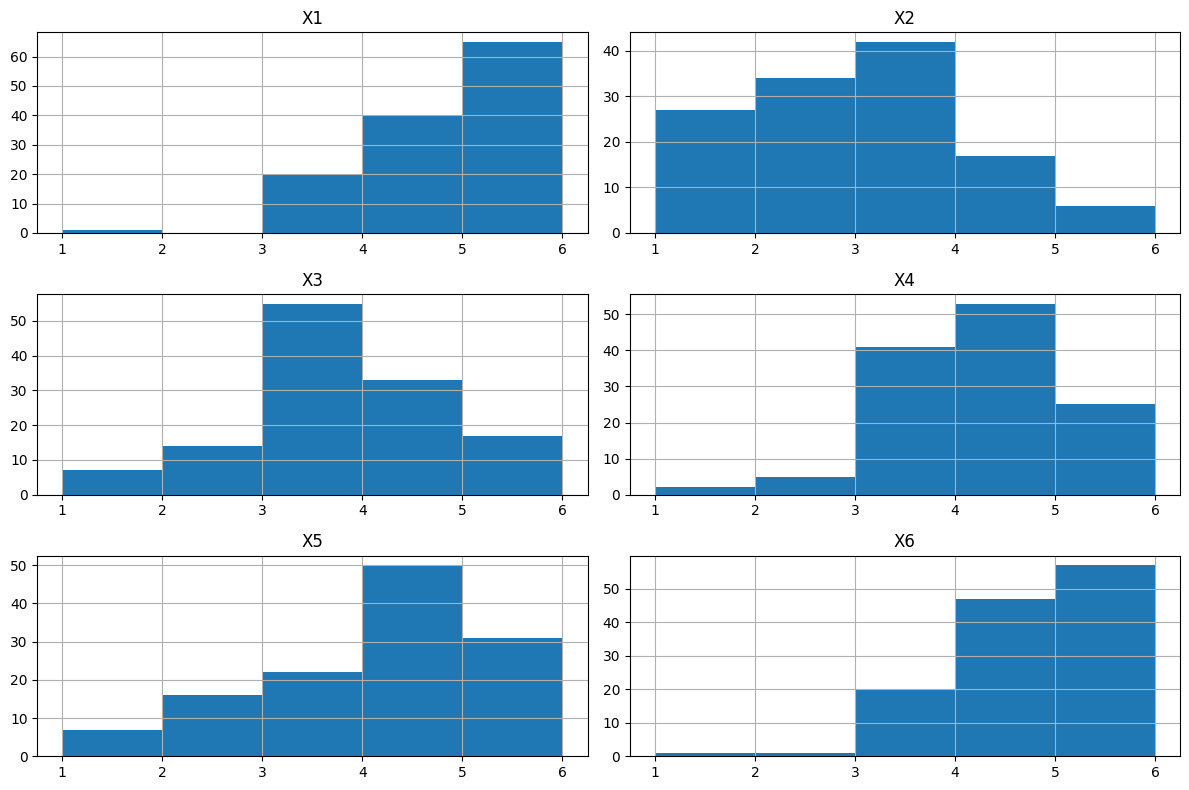

In [15]:
import matplotlib.pyplot as plt

df[["X1", "X2", "X3", "X4", "X5", "X6"]].hist(
    bins=range(1, 7),
    figsize=(12, 8)
)

plt.tight_layout()
plt.show()

In [16]:
#Variation of all the answers for all questions
#lower std answers are mostly similar ; higher answers are spread out
df[["X1", "X2", "X3", "X4", "X5", "X6"]].std()

,0
X1,0.800000
X2,1.114892
X3,1.023440
X4,0.875776
X5,1.147641
X6,0.809311


In [17]:
features = ["X1", "X2", "X3", "X4", "X5", "X6"]

average_by_target = df.groupby("Y")[features].mean().T
average_by_target.columns = ["Unhappy", "Happy"]

average_by_target["Difference"] = (
    average_by_target["Happy"] - average_by_target["Unhappy"]
)

average_by_target.sort_values(
    by="Difference",
    key=abs,
    ascending=False
)

,Unhappy,Happy,Difference
X5,3.368421,3.884058,0.515637
X1,4.087719,4.536232,0.448513
X3,3.140351,3.449275,0.308924
X6,4.105263,4.376812,0.271548
X4,3.684211,3.797101,0.112891
X2,2.561404,2.507246,-0.054157


In [18]:
correlation_with_target = (
    df[features + ["Y"]]
    .corr()["Y"]
    .drop("Y")
    .sort_values(key=abs, ascending=False)
)

print(correlation_with_target)

X1    0.280160
X5    0.224522
X6    0.167669
X3    0.150838
X4    0.064415
X2   -0.024274
Name: Y, dtype: float64


In [19]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

X = df[features]
y = df["Y"]

mi_scores = mutual_info_classif(
    X,
    y,
    discrete_features=True,
    random_state=42
)

mi_results = pd.DataFrame({
    "Feature": features,
    "Mutual Information": mi_scores
}).sort_values(
    by="Mutual Information",
    ascending=False
)

print(mi_results)

  Feature  Mutual Information
0      X1            0.049705
5      X6            0.035543
4      X5            0.027627
3      X4            0.021880
2      X3            0.017432
1      X2            0.009468


In [20]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import pandas as pd

X = df[features]
y = df["Y"]

logistic_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        random_state=42,
        max_iter=1000
    ))
])

logistic_pipeline.fit(X, y)

coefficients = logistic_pipeline.named_steps["model"].coef_[0]

coefficient_results = pd.DataFrame({
    "Feature": features,
    "Coefficient": coefficients,
    "Absolute Importance": abs(coefficients)
}).sort_values(
    by="Absolute Importance",
    ascending=False
)

print(coefficient_results)

  Feature  Coefficient  Absolute Importance
0      X1     0.438742             0.438742
4      X5     0.230172             0.230172
2      X3     0.131656             0.131656
1      X2    -0.098792             0.098792
5      X6     0.072604             0.072604
3      X4    -0.004282             0.004282


In [21]:
#Feature Elimination
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=10,
    random_state=42
)

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=3,
    min_samples_leaf=3,
    random_state=42
)

results = []

full_scores = cross_val_score(
    model,
    df[features],
    y,
    cv=cv,
    scoring="accuracy"
)

results.append({
    "Features Used": "All features",
    "Removed Feature": "None",
    "Mean Accuracy": full_scores.mean(),
    "Standard Deviation": full_scores.std()
})

for removed_feature in features:
    remaining_features = [
        feature for feature in features
        if feature != removed_feature
    ]

    scores = cross_val_score(
        model,
        df[remaining_features],
        y,
        cv=cv,
        scoring="accuracy"
    )

    results.append({
        "Features Used": ", ".join(remaining_features),
        "Removed Feature": removed_feature,
        "Mean Accuracy": scores.mean(),
        "Standard Deviation": scores.std()
    })

ablation_results = pd.DataFrame(results).sort_values(
    by="Mean Accuracy",
    ascending=False
)

print(ablation_results)

        Features Used Removed Feature  Mean Accuracy  Standard Deviation
6  X1, X2, X3, X4, X5              X6       0.601723            0.075663
2  X1, X3, X4, X5, X6              X2       0.581015            0.075329
4  X1, X2, X3, X5, X6              X4       0.580185            0.078971
3  X1, X2, X4, X5, X6              X3       0.580123            0.076566
0        All features            None       0.579292            0.074821
5  X1, X2, X3, X4, X6              X5       0.571569            0.080341
1  X2, X3, X4, X5, X6              X1       0.546923            0.080999


In [22]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# ---------------------------------------------------------
# 1. Load the dataset
# ---------------------------------------------------------

df = pd.read_csv("ACME-HappinessSurvey2020.csv")

# X contains the survey questions
X = df[["X1", "X2", "X3", "X4", "X5", "X6"]]

# y contains the target:
# 0 = unhappy
# 1 = happy
y = df["Y"]

# ---------------------------------------------------------
# 2. Divide data into training and testing sets
# ---------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# stratify=y keeps approximately the same proportion
# of happy and unhappy customers in both datasets.

# ---------------------------------------------------------
# 3. Define classification models
# ---------------------------------------------------------

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=3,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=3,
        min_samples_leaf=2,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),

    "Support Vector Machine": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(
            kernel="rbf",
            probability=True,
            random_state=42
        ))
    ]),

    "K-Nearest Neighbors": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(
            n_neighbors=5
        ))
    ])
}

# ---------------------------------------------------------
# 4. Train and evaluate every model
# ---------------------------------------------------------

results = []

for model_name, model in models.items():

    # Train model
    model.fit(X_train, y_train)

    # Predict classes
    y_pred = model.predict(X_test)

    # Predict probabilities for ROC-AUC
    y_probability = model.predict_proba(X_test)[:, 1]

    # Calculate evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test,
        y_probability
    )

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    })

# ---------------------------------------------------------
# 5. Display results
# ---------------------------------------------------------

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

print(results_df.round(3))

                    Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
1           Decision Tree     0.808      0.737   1.000     0.848    0.878
2           Random Forest     0.769      0.722   0.929     0.812    0.821
0     Logistic Regression     0.615      0.600   0.857     0.706    0.750
4  Support Vector Machine     0.615      0.611   0.786     0.688    0.744
5     K-Nearest Neighbors     0.615      0.600   0.857     0.706    0.554
3       Gradient Boosting     0.538      0.562   0.643     0.600    0.607
